# SINDy Feature Engineering — Towards R² ≈ 1

**Goal:** Find the smallest SINDy dictionary that achieves R² close to 1, enabling a
clean demonstration of the behavioral cloning compounding-error phenomenon.

## Why the polynomial-on-state-6 approach falls short

The PPO expert maps a 9-dim observation
$[x,\, \sin\theta_1,\, \sin\theta_2,\, \cos\theta_1,\, \cos\theta_2,\, \dot{x},\, \dot{\theta}_1,\, \dot{\theta}_2,\, f_c]$
to a cart force. The pendulum dynamics contain $\sin\theta$ and $\cos\theta$ naturally —
gravity and centripetal terms all involve trig functions of the angles. A polynomial in
raw angles approximates these via Taylor series, requiring high degree to be accurate.
With degree 2–5 we top out at R²≈0.90.

## Strategy

Compare four feature sets, then sweep STLSQ threshold on the winner:

| ID | Input | Library | Notes |
|----|-------|---------|-------|
| A | state-6 | poly deg 2–4 | baseline |
| B | obs-9 | poly deg 2–3 | sin/cos already present |
| C | state-6 + trig | poly deg 2 | explicit sin/cos appended |
| D | state-6 + trig | poly deg 2, standardized | adds input scaling |

In [8]:
%load_ext autoreload
%autoreload 2

import sys
import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pysindy as ps
import gymnasium as gym
from sklearn.preprocessing import StandardScaler
from joblib import Parallel, delayed
from tqdm.auto import tqdm
from collections import defaultdict
from stable_baselines3 import PPO

# Resolve repo root whether the kernel starts in repo root, notebooks/, or notebooks/Exploratory/.
CWD = pathlib.Path.cwd().resolve()
PROJECT_ROOT = next(p for p in [CWD, *CWD.parents] if (p / "pyproject.toml").exists())
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))
from plotting_utils import plot_eval_bars, render_episode, plot_phase_portraits, plot_pca_coverage

DATA_PATH  = PROJECT_ROOT / "data" / "trajectories_baseline.npz"
CHECKPOINT = str(PROJECT_ROOT / "notebooks" / "checkpoints" / "baseline" / "best_model.zip")
ENV_ID     = "InvertedDoublePendulum-v5"
STATE_LABELS = ["x", "θ₁", "θ₂", "ẋ", "θ̇₁", "θ̇₂"]
N_EVAL     = 20
STLSQ_THRS = 0.01

_env      = gym.make(ENV_ID)
MAX_STEPS = _env.spec.max_episode_steps
DT        = _env.unwrapped.dt
EVAL_NOISE = getattr(_env.unwrapped, "reset_noise_scale",
                     getattr(_env.unwrapped, "_reset_noise_scale", 0.1))
_env.close()
print(f"MAX_STEPS={MAX_STEPS}  DT={DT}  EVAL_NOISE={EVAL_NOISE}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
MAX_STEPS=1000  DT=0.05  EVAL_NOISE=0.1


In [9]:
data   = np.load(DATA_PATH)
X6     = data["X"].astype(np.float64)   # (N, 6) physical state
U      = data["U"].astype(np.float64)   # (N, 1)
if U.ndim == 1:
    U = U.reshape(-1, 1)

# 9-dim observation (sin/cos already present; drop f_constraint col 8)
def obs_to_state6(obs):
    return np.array([
        obs[0],
        np.arctan2(obs[1], obs[3]), np.arctan2(obs[2], obs[4]),
        obs[5], obs[6], obs[7],
    ], dtype=np.float64)

def state6_to_obs8(s):
    """6-dim state → 8-dim obs (drop constraint force)."""
    x, th1, th2, xd, th1d, th2d = s
    return np.array([
        x, np.sin(th1), np.sin(th2), np.cos(th1), np.cos(th2),
        xd, th1d, th2d,
    ], dtype=np.float64)

X8 = np.array([state6_to_obs8(s) for s in X6])   # (N, 8) — obs without f_c

# state-6 + explicit trig: [x, θ₁, θ₂, ẋ, θ̇₁, θ̇₂, sin(θ₁), cos(θ₁), sin(θ₂), cos(θ₂)]
X10 = np.hstack([
    X6,
    np.sin(X6[:, 1:2]), np.cos(X6[:, 1:2]),
    np.sin(X6[:, 2:3]), np.cos(X6[:, 2:3]),
])

print(f"X6  shape: {X6.shape}")
print(f"X8  shape: {X8.shape}   (obs-8, sin/cos of angles included)")
print(f"X10 shape: {X10.shape}  (state-6 + trig)")

X6  shape: (50000, 6)
X8  shape: (50000, 8)   (obs-8, sin/cos of angles included)
X10 shape: (50000, 10)  (state-6 + trig)


---

## Phase 1 — R² and sparsity sweep across feature sets and degrees

In [10]:
def fit_report(X_in, U, degree, threshold, scaler=None):
    """Fit STLSQ on X_in; return dict of fit metadata."""
    if scaler is not None:
        X_fit = scaler.fit_transform(X_in)
    else:
        X_fit = X_in
        scaler = None

    lib   = ps.PolynomialLibrary(degree=degree)
    lib.fit(X_fit)
    Theta = lib.transform(X_fit)
    coeff = ps.STLSQ(threshold=threshold).fit(Theta, U).coef_

    nf   = Theta.shape[1]
    nz   = int(np.sum(np.abs(coeff) > 1e-8))
    up   = np.asarray((Theta @ coeff.T).flatten())
    rmse = float(np.sqrt(np.mean((U.flatten() - up) ** 2)))
    r2   = float(1.0 - np.sum((U.flatten() - up)**2) /
                       np.sum((U.flatten() - U.mean())**2))
    return dict(lib=lib, coeff=coeff, scaler=scaler,
                nf=nf, nz=nz, rmse=rmse, r2=r2)


configs = [
    # (label, X_in, degree, use_scaler)
    ("A — state-6, deg2",          X6,  2, False),
    ("A — state-6, deg3",          X6,  3, False),
    ("A — state-6, deg4",          X6,  4, False),
    ("B — obs-8 (sin/cos), deg2",  X8,  2, False),
    ("B — obs-8 (sin/cos), deg3",  X8,  3, False),
    ("C — state-6+trig, deg2",     X10, 2, False),
    ("C — state-6+trig, deg3",     X10, 3, False),
    ("D — state-6+trig, deg2, std",X10, 2, True),
    ("D — state-6+trig, deg3, std",X10, 3, True),
]

def _run(label, X_in, degree, use_scaler):
    scaler = StandardScaler() if use_scaler else None
    r = fit_report(X_in, U, degree, STLSQ_THRS, scaler)
    return label, r

fit_results = dict(Parallel(n_jobs=-1, prefer="threads")(
    delayed(_run)(label, X_in, deg, sc)
    for label, X_in, deg, sc in configs
))

pd.DataFrame([
    {"config": lbl,
     "features": r["nf"], "nonzero": r["nz"],
     "sparsity": f"{100*(1-r['nz']/r['nf']):.0f}%",
     "RMSE": round(r["rmse"], 4), "R²": round(r["r2"], 4)}
    for lbl, r in fit_results.items()
]).set_index("config")

,features,nonzero,sparsity,RMSE,R²
config,,,,,
"A — state-6, deg2",28,27,4%,0.2638,0.8254
"A — state-6, deg3",84,81,4%,0.2132,0.8859
"A — state-6, deg4",210,206,2%,0.2071,0.8924
"B — obs-8 (sin/cos), deg2",45,45,0%,0.2348,0.8617
"B — obs-8 (sin/cos), deg3",165,161,2%,0.2064,0.8931
"C — state-6+trig, deg2",66,65,2%,0.2303,0.8669
"C — state-6+trig, deg3",286,274,4%,0.2019,0.8977
"D — state-6+trig, deg2, std",66,63,5%,0.2302,0.8671
"D — state-6+trig, deg3, std",286,228,20%,0.2019,0.8977


---

## Phase 2 — Threshold sweep on best-R² config

For the configuration with the highest R², sweep the STLSQ threshold to find the
sparsest model that doesn't sacrifice R².

In [11]:
# identify best config by R²
best_label = max(fit_results, key=lambda k: fit_results[k]["r2"])
best_cfg   = next(c for c in configs if c[0] == best_label)
_, X_best, deg_best, sc_best = best_cfg
print(f"Best config: {best_label}  R²={fit_results[best_label]['r2']:.4f}")

THRESHOLDS = [0.001, 0.005, 0.01, 0.02, 0.05, 0.1, 0.2, 0.3, 0.5]

def _run_thr(thr):
    scaler = StandardScaler() if sc_best else None
    return thr, fit_report(X_best, U, deg_best, thr, scaler)

thr_results = dict(Parallel(n_jobs=-1, prefer="threads")(
    delayed(_run_thr)(thr) for thr in THRESHOLDS
))

thr_df = pd.DataFrame([
    {"threshold": thr, "nonzero": r["nz"], "total": r["nf"],
     "sparsity": f"{100*(1-r['nz']/r['nf']):.0f}%",
     "RMSE": round(r["rmse"], 4), "R²": round(r["r2"], 4)}
    for thr, r in sorted(thr_results.items())
]).set_index("threshold")
thr_df

Best config: D — state-6+trig, deg3, std  R²=0.8977


,nonzero,total,sparsity,RMSE,R²
threshold,,,,,
0.001,277,286,3%,0.2016,0.8980
0.005,258,286,10%,0.2016,0.8980
0.010,228,286,20%,0.2019,0.8977
0.020,187,286,35%,0.2033,0.8963
0.050,118,286,59%,0.2079,0.8915
0.100,73,286,74%,0.2100,0.8893
0.200,36,286,87%,0.2830,0.7991
0.300,38,286,87%,0.2857,0.7952
0.500,1,286,100%,0.3518,0.6893


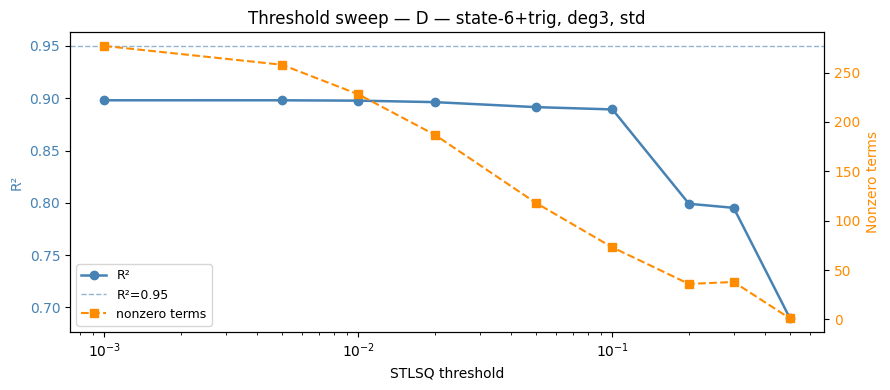

In [12]:
fig, ax1 = plt.subplots(figsize=(9, 4))
thrs  = sorted(thr_results)
r2s   = [thr_results[t]["r2"]  for t in thrs]
nzs   = [thr_results[t]["nz"]  for t in thrs]

ax1.semilogx(thrs, r2s, "o-", color="steelblue", lw=1.8, ms=6, label="R²")
ax1.axhline(0.95, color="steelblue", ls="--", lw=1, alpha=0.6, label="R²=0.95")
ax1.set_xlabel("STLSQ threshold")
ax1.set_ylabel("R²", color="steelblue")
ax1.tick_params(axis="y", labelcolor="steelblue")

ax2 = ax1.twinx()
ax2.semilogx(thrs, nzs, "s--", color="darkorange", lw=1.5, ms=6, label="nonzero terms")
ax2.set_ylabel("Nonzero terms", color="darkorange")
ax2.tick_params(axis="y", labelcolor="darkorange")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=9)
ax1.set_title(f"Threshold sweep — {best_label}")
plt.tight_layout()
plt.show()

---

## Phase 2b — Post-hoc least-squares refit

STLSQ's iterative thresholding finds *which* terms to keep but does not guarantee
optimal *coefficients* for those terms — each threshold step discards features and
refits, introducing bias. Once the sparsity pattern is fixed, we can re-solve
unconstrained least squares on only the surviving columns. This costs nothing and
often recovers several R² points with the same sparsity.

In [13]:
def posthoc_refit(fit, X_in, U):
    """Re-solve LS on STLSQ's sparsity pattern; return updated fit dict."""
    scaler = fit["scaler"]
    X_fit  = scaler.transform(X_in) if scaler is not None else X_in
    Theta  = fit["lib"].transform(X_fit)

    active = np.where(np.abs(fit["coeff"]).flatten() > 1e-8)[0]
    if len(active) == 0:
        return fit  # nothing survived thresholding

    coeff_ls, _, _, _ = np.linalg.lstsq(Theta[:, active], U, rcond=None)
    coeff_full = np.zeros_like(fit["coeff"])
    coeff_full[:, active] = coeff_ls.T

    up   = np.asarray((Theta @ coeff_full.T).flatten())
    rmse = float(np.sqrt(np.mean((U.flatten() - up) ** 2)))
    r2   = float(1.0 - np.sum((U.flatten() - up)**2) /
                       np.sum((U.flatten() - U.mean())**2))

    return {**fit, "coeff": coeff_full, "rmse": rmse, "r2": r2}


refit_results = {thr: posthoc_refit(r, X_best, U)
                 for thr, r in thr_results.items()}

rows = []
for thr in sorted(thr_results):
    before = thr_results[thr]
    after  = refit_results[thr]
    rows.append({
        "threshold": thr,
        "nonzero":   after["nz"],
        "R² (STLSQ)":   round(before["r2"], 4),
        "R² (post-hoc)": round(after["r2"],  4),
        "ΔR²":           round(after["r2"] - before["r2"], 4),
    })

pd.DataFrame(rows).set_index("threshold")

,nonzero,R² (STLSQ),R² (post-hoc),ΔR²
threshold,,,,
0.001,277,0.8980,0.8980,0.0
0.005,258,0.8980,0.8980,0.0
0.010,228,0.8977,0.8977,0.0
0.020,187,0.8963,0.8963,0.0
0.050,118,0.8915,0.8915,0.0
0.100,73,0.8893,0.8893,0.0
0.200,36,0.7991,0.7991,0.0
0.300,38,0.7952,0.7952,0.0
0.500,1,0.6893,0.6893,0.0


---

## Phase 2c — SR3 optimizer

SR3 (Sparse Relaxed Regularized Regression) replaces STLSQ's hard thresholding with
a smooth relaxation: it introduces an auxiliary variable $W$ and penalises
$\|W\|_0$ while allowing $W$ to deviate from the coefficients by at most $\nu^{-1}$.
This avoids the greedy bias of iterative hard thresholding and often finds sparser
solutions at the same R², or higher R² at the same sparsity.

In [14]:
def fit_sr3(X_in, U, degree, lam=0.005, nu=1.0, scaler=None):
    if scaler is not None:
        X_fit = scaler.fit_transform(X_in)
    else:
        X_fit = X_in
    lib   = ps.PolynomialLibrary(degree=degree)
    lib.fit(X_fit)
    Theta = lib.transform(X_fit)
    opt   = ps.SR3(reg_weight_lam=lam, relax_coeff_nu=nu, max_iter=10_000)
    opt.fit(Theta, U)
    coeff = opt.coef_

    nf   = Theta.shape[1]
    nz   = int(np.sum(np.abs(coeff) > 1e-8))
    up   = np.asarray((Theta @ coeff.T).flatten())
    rmse = float(np.sqrt(np.mean((U.flatten() - up) ** 2)))
    r2   = float(1.0 - np.sum((U.flatten() - up)**2) /
                       np.sum((U.flatten() - U.mean())**2))
    return dict(lib=lib, coeff=coeff, scaler=scaler,
                nf=nf, nz=nz, rmse=rmse, r2=r2)


LAM_VALUES = [0.001, 0.005, 0.01, 0.05, 0.1, 0.2]
NU_VALUES  = [0.1, 1.0, 10.0]
sr3_configs = [(lam, nu) for lam in LAM_VALUES for nu in NU_VALUES]

def _run_sr3(lam, nu):
    scaler = StandardScaler() if sc_best else None
    return (lam, nu), fit_sr3(X_best, U, deg_best, lam, nu, scaler)

sr3_results = dict(Parallel(n_jobs=-1, prefer="threads")(
    delayed(_run_sr3)(lam, nu) for lam, nu in tqdm(sr3_configs, desc="SR3 sweep")
))

sr3_rows = []
for (lam, nu), r in sorted(sr3_results.items()):
    sr3_rows.append({
        "lam": lam, "nu": nu,
        "nonzero":  r["nz"],
        "sparsity": f"{100*(1-r['nz']/r['nf']):.0f}%",
        "RMSE":     round(r["rmse"], 4),
        "R²":       round(r["r2"],   4),
    })

sr3_df = pd.DataFrame(sr3_rows).set_index(["lam", "nu"])
sr3_df

SR3 sweep:   0%|          | 0/18 [00:00<?, ?it/s]

/Users/patrick/Documents/personal/UW/ME_595/.venv/lib/python3.14/site-packages/pysindy/optimizers/sr3.py:374: ConvergenceWarning: SR3 did not converge after 10000 iterations.
  warnings.warn(
/Users/patrick/Documents/personal/UW/ME_595/.venv/lib/python3.14/site-packages/pysindy/optimizers/sr3.py:374: ConvergenceWarning: SR3 did not converge after 10000 iterations.
  warnings.warn(
/Users/patrick/Documents/personal/UW/ME_595/.venv/lib/python3.14/site-packages/pysindy/optimizers/sr3.py:374: ConvergenceWarning: SR3 did not converge after 10000 iterations.
  warnings.warn(
/Users/patrick/Documents/personal/UW/ME_595/.venv/lib/python3.14/site-packages/pysindy/optimizers/sr3.py:374: ConvergenceWarning: SR3 did not converge after 10000 iterations.
  warnings.warn(


nonzero sparsity     RMSE        R²
lam   nu                                       
0.001 0.1       271       5%   0.2241    0.8739
      1.0       261       9%   0.9544   -1.2860
      10.0      249      13%   3.6660  -32.7250
0.005 0.1       265       7%   0.6402   -0.0284
      1.0       255      11%   3.1360  -23.6787
      10.0      231      19%  12.5618 -394.9829
0.010 0.1       262       8%   0.7256   -0.3212
      1.0       248      13%   2.9539  -20.8957
      10.0      223      22%   4.7553  -55.7451
0.050 0.1       251      12%   2.4054  -13.5190
      1.0       235      18%   2.8226  -18.9932
      10.0      204      29%   4.1389  -41.9872
0.100 0.1       247      14%   2.3817  -13.2343
      1.0       226      21%   7.3950 -136.2299
      10.0      203      29%   3.8514  -36.2222
0.200 0.1       239      16%   2.4939  -14.6069
      1.0       219      23%   7.3867 -135.9235
      10.0      201      30%   3.8998  -37.1636

In [15]:
best_refit = max(refit_results.items(), key=lambda kv: kv[1]["r2"])
best_sr3   = max(sr3_results.items(),   key=lambda kv: kv[1]["r2"])

print("── Best per approach ────────────────────────────────────────")
print(f"STLSQ (raw)     thr={best_label:<6}  R²={fit_results[best_label]['r2']:.4f}")
print(f"Post-hoc refit  thr={best_refit[0]:<6}  R²={best_refit[1]['r2']:.4f}  "
      f"nz={best_refit[1]['nz']}")
print(f"SR3             lam={best_sr3[0][0]:<6}  nu={best_sr3[0][1]:<5}  "
      f"R²={best_sr3[1]['r2']:.4f}  nz={best_sr3[1]['nz']}")

candidates = {
    "STLSQ":       fit_results[best_label],
    "Post-hoc LS": best_refit[1],
    "SR3":         best_sr3[1],
}
WINNER_LABEL = max(candidates, key=lambda k: candidates[k]["r2"])
WINNER_FIT   = candidates[WINNER_LABEL]
print(f"\n>>> Winner: {WINNER_LABEL}  R²={WINNER_FIT['r2']:.4f}  nz={WINNER_FIT['nz']}")

── Best per approach ────────────────────────────────────────
STLSQ (raw)     thr=D — state-6+trig, deg3, std  R²=0.8977
Post-hoc refit  thr=0.001   R²=0.8980  nz=277
SR3             lam=0.001   nu=0.1    R²=0.8739  nz=271

>>> Winner: Post-hoc LS  R²=0.8980  nz=277


---

## Phase 3 — Select final model and evaluate closed-loop

In [16]:
final_fit = WINNER_FIT

print(f"Selected approach  : {WINNER_LABEL}")
print(f"Feature set        : {best_label}")
print(f"Nonzero terms      : {final_fit['nz']} / {final_fit['nf']}")
print(f"Sparsity           : {100*(1-final_fit['nz']/final_fit['nf']):.0f}%")
print(f"RMSE               : {final_fit['rmse']:.4f}")
print(f"R²                 : {final_fit['r2']:.4f}")

Selected approach  : Post-hoc LS
Feature set        : D — state-6+trig, deg3, std
Nonzero terms      : 277 / 286
Sparsity           : 3%
RMSE               : 0.2016
R²                 : 0.8980


In [17]:
def make_policy(fit, X_raw_fn):
    """Returns policy_fn(obs9) -> action array.
    X_raw_fn: maps obs (9-dim) to the raw feature input used for this fit.
    """
    lib    = fit["lib"]
    coeff  = fit["coeff"]
    scaler = fit["scaler"]

    def policy(obs):
        x = np.asarray(X_raw_fn(obs), dtype=np.float64).reshape(1, -1)
        if scaler is not None:
            x = scaler.transform(x)
        Th = lib.transform(x)
        u  = float(np.asarray(Th @ coeff.T).flatten()[0])
        return np.array([np.clip(u, -1.0, 1.0)], dtype=np.float32)
    return policy


# choose the input-mapping function matching the best config
def _obs9_to_input(obs):
    s = obs_to_state6(obs)
    if   "obs-8"      in best_label: return state6_to_obs8(s)
    elif "state-6+trig" in best_label:
        return np.concatenate([s,
                               [np.sin(s[1]), np.cos(s[1]),
                                np.sin(s[2]), np.cos(s[2])]])
    else: return s   # plain state-6

final_policy = make_policy(final_fit, _obs9_to_input)

# quick nominal rollout
env = gym.make(ENV_ID, reset_noise_scale=EVAL_NOISE)
obs, _ = env.reset(seed=0)
ep_l = 0; done = False
while not done:
    obs, _, terminated, truncated, _ = env.step(final_policy(obs))
    ep_l += 1; done = terminated or truncated
env.close()
print(f"Nominal rollout: {ep_l} / {MAX_STEPS} steps  "
      f"({'COMPLETE ✓' if ep_l >= MAX_STEPS else 'FAILED'})")

Nominal rollout: 1000 / 1000 steps  (COMPLETE ✓)


In [18]:
render_episode(final_policy, ENV_ID, MAX_STEPS, DT,
               title=f"Final SINDy policy — {best_label}", seed=0)

1000 / 1000 steps  (50.0 s)  ← TASK COMPLETE


In [ ]:
_r2 = final_fit["r2"]
print(f"R² = {_r2:.4f}")
assert _r2 >= 0.95, (
    f"R²={_r2:.4f} is below 0.95 — fit quality is insufficient to cleanly demonstrate "
    f"the BC compounding-error phenomenon. Adjust feature set, degree, or threshold "
    f"in Phase 1–2 above to achieve R²≥0.95 before proceeding."
)

---

## Phase 4 — Behavioral cloning compounding error demonstration

With R² close to 1, we can now properly demonstrate the BC compounding error.
The perturbation sweep should show a clear cliff — the policy succeeds at low noise
but fails sharply once the initial state leaves the region the polynomial was fit on.

In [19]:
NOISE_LEVELS = [0.01, 0.05, 0.1, 0.15, 0.2, 0.3, 0.4, 0.5]

def _run_episode(fit, X_raw_fn, env_id, noise, seed):
    import numpy as np, gymnasium as gym

    lib    = fit["lib"]
    coeff  = fit["coeff"]
    scaler = fit["scaler"]

    def policy(obs):
        x = np.asarray(X_raw_fn(obs), dtype=np.float64).reshape(1, -1)
        if scaler is not None:
            x = scaler.transform(x)
        Th = lib.transform(x)
        u  = float(np.asarray(Th @ coeff.T).flatten()[0])
        return np.array([np.clip(u, -1.0, 1.0)], dtype=np.float32)

    env = gym.make(env_id, reset_noise_scale=noise)
    obs, _ = env.reset(seed=seed)
    ep_l = ep_r = 0; done = False
    while not done:
        obs, r, terminated, truncated, _ = env.step(policy(obs))
        ep_l += 1; ep_r += r; done = terminated or truncated
    env.close()
    return ep_l, ep_r

sweep_tasks = [(σ, ep) for σ in NOISE_LEVELS for ep in range(10)]
sweep_raw = list(tqdm(
    Parallel(n_jobs=-1, prefer="threads", return_as="generator")(
        delayed(_run_episode)(final_fit, _obs9_to_input, ENV_ID, σ, seed)
        for σ, seed in sweep_tasks
    ),
    total=len(sweep_tasks), desc="Perturbation sweep", unit="ep",
))

buckets = defaultdict(list)
for (σ, _), (ep_l, _) in zip(sweep_tasks, sweep_raw):
    buckets[σ].append(ep_l)

sweep_means = {σ: float(np.mean(buckets[σ])) for σ in NOISE_LEVELS}
for σ, m in sweep_means.items():
    print(f"  noise_std={σ:.2f}  mean_ep_len={m:.0f} / {MAX_STEPS}")

BC_DEMO_NOISE = next(
    (σ for σ in NOISE_LEVELS if sweep_means[σ] < 800),
    NOISE_LEVELS[-1],
)
print(f"\nBC_DEMO_NOISE = {BC_DEMO_NOISE}")

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(NOISE_LEVELS, [sweep_means[σ] for σ in NOISE_LEVELS],
        "o-", color="steelblue", lw=1.8, ms=6)
ax.axhline(MAX_STEPS, color="green", ls="--", lw=1.5, label=f"max ({MAX_STEPS} steps)")
ax.axvline(BC_DEMO_NOISE, color="crimson", ls=":", lw=1.5,
           label=f"BC demo (σ={BC_DEMO_NOISE})")
ax.set_xlabel("Reset noise std")
ax.set_ylabel("Mean episode length")
ax.set_title("Perturbation robustness — final SINDy policy")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

: 

: 

In [ ]:
# failing rollout at BC_DEMO_NOISE
env = gym.make(ENV_ID, reset_noise_scale=BC_DEMO_NOISE)
obs, _ = env.reset(seed=42)
states, actions = [], []
done = False
while not done:
    states.append(obs_to_state6(obs))
    action = final_policy(obs)
    obs, _, terminated, truncated, _ = env.step(action)
    actions.append(float(action[0]))
    done = terminated or truncated
env.close()

states_demo = np.array(states)
print(f"Demo rollout (σ={BC_DEMO_NOISE}): {len(actions)} / {MAX_STEPS} steps")

plot_pca_coverage(
    X6, overlay=states_demo,
    overlay_label=f"SINDy rollout (σ={BC_DEMO_NOISE})",
    overlay_color="crimson",
    title="PCA — does the failing trajectory leave the training cloud?",
)